# Netflix Text and Document Clustering

In [7]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from yellowbrick.cluster import KElbowVisualizer
import numpy as np

In [2]:
df = pd.read_csv("Netflix_movies_and_tv_shows_clustering.csv")

In [3]:
documents = df["description"].dropna()

In [4]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
x_tfidf = vectorizer.fit_transform(documents)

In [8]:
x_array = np.asarray(x_tfidf.toarray())

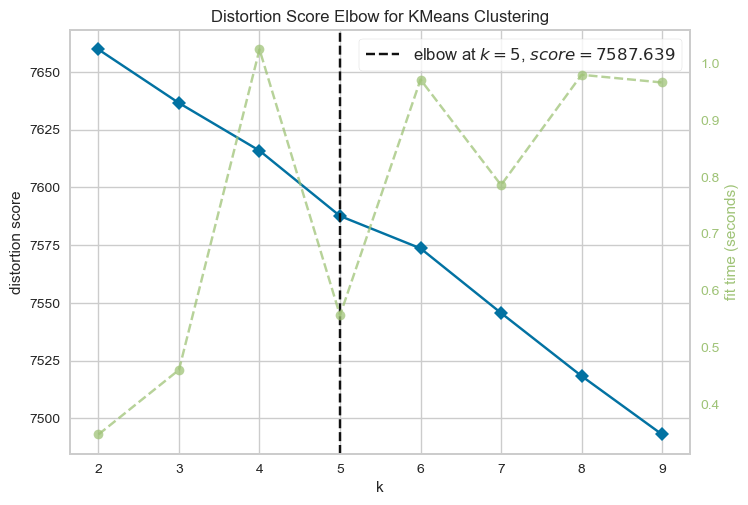

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
model = KMeans(random_state=42)
vis = KElbowVisualizer(model, k=(2, 10))
vis.fit(x_array)  
vis.show()

In [10]:
optimal_k = vis.elbow_value_ if vis.elbow_value_ is not None else 5

In [11]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(x_array)

In [12]:
clustered_df = pd.DataFrame({"Description": documents, "Cluster": clusters})

In [13]:
clustered_df["Cluster"].value_counts()

Cluster
4    4929
1    1043
2     948
0     588
3     279
Name: count, dtype: int64

In [14]:
joblib.dump(kmeans, "document_clustering_model.pkl")

['document_clustering_model.pkl']